/tmp/ipykernel_1172/2752649766.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  veri = yf.download(hisse_kodu, start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.232376  40.241720  39.531708  39.741910  102223600
2018-01-03  40.225368  40.767220  40.162311  40.295436  118071600
2018-01-04  40.412212  40.514978  40.190335  40.297769   89738400
2018-01-05  40.872330  40.958744  40.416896  40.507983   94640000
2018-01-08  40.720520  41.014800  40.622423  40.720520   82271200


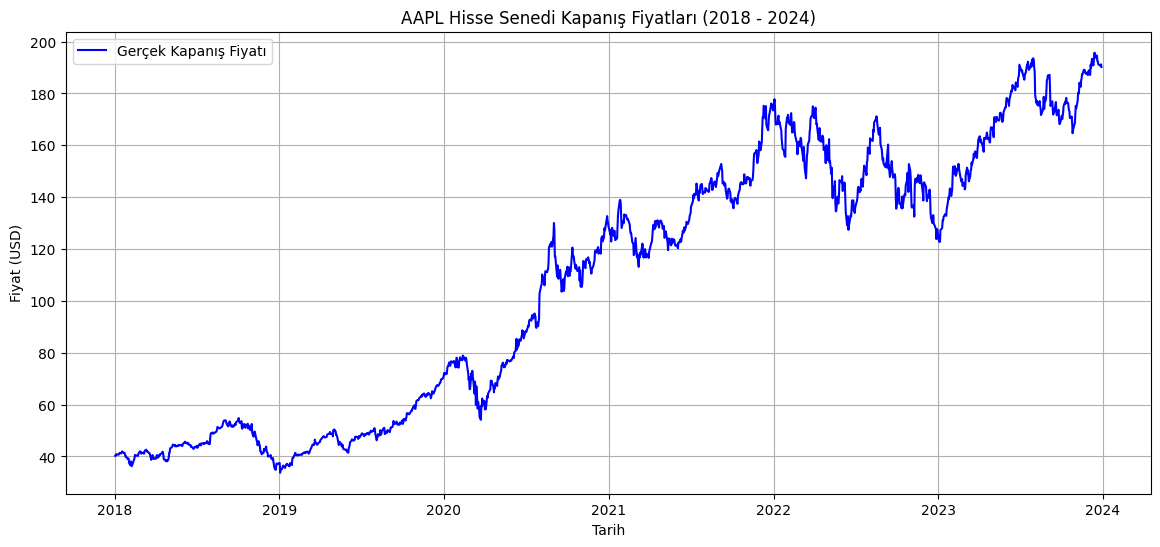

In [19]:
!pip install -q yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

hisse_kodu = 'AAPL'
veri = yf.download(hisse_kodu, start='2018-01-01', end='2024-01-01')
print(veri.head())
plt.figure(figsize=(14,6))
plt.plot(veri['Close'], label='Gerçek Kapanış Fiyatı', color='blue')
plt.title(f"{hisse_kodu} Hisse Senedi Kapanış Fiyatları (2018 - 2024)")
plt.xlabel("Tarih")
plt.ylabel("Fiyat (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

kapanis_verisi = veri['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
olcekli_veri = scaler.fit_transform(kapanis_verisi)

egitim_veri_uzunlugu = int(np.ceil(len(kapanis_verisi) * .8))
egitim_verisi = olcekli_veri[0:int(egitim_veri_uzunlugu), :]

x_train = []
y_train = []

for i in range(60, len(egitim_verisi)):
    x_train.append(egitim_verisi[i-60:i, 0])
    y_train.append(egitim_verisi[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Eğitim verisi tıkır tıkır hazır! x_train boyutu: {x_train.shape}")

Eğitim verisi tıkır tıkır hazır! x_train boyutu: (1148, 60, 1)


In [21]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan İşlem Birimi: {device}")

x_train_tensor = torch.from_numpy(x_train).type(torch.Tensor).to(device)
y_train_tensor = torch.from_numpy(y_train).type(torch.Tensor).to(device)

class BorsaKahiniLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        tahmin = self.linear(lstm_out[:, -1, :])
        return tahmin

model = BorsaKahiniLSTM().to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("PyTorch LSTM Modeli (Borsa Kahini) başarıyla kuruldu!")
print(model)

Kullanılan İşlem Birimi: cpu
PyTorch LSTM Modeli (Borsa Kahini) başarıyla kuruldu!
BorsaKahiniLSTM(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


Yapay Zeka antrenmana başlıyor, geçmişten öğreniyor...
Epoch [2/100], Hata (Loss): 0.254495
Epoch [4/100], Hata (Loss): 0.226082
Epoch [6/100], Hata (Loss): 0.199318
Epoch [8/100], Hata (Loss): 0.173950
Epoch [10/100], Hata (Loss): 0.149838
Epoch [12/100], Hata (Loss): 0.127006
Epoch [14/100], Hata (Loss): 0.105672
Epoch [16/100], Hata (Loss): 0.086349
Epoch [18/100], Hata (Loss): 0.070065
Epoch [20/100], Hata (Loss): 0.058680
Epoch [22/100], Hata (Loss): 0.054964
Epoch [24/100], Hata (Loss): 0.059644
Epoch [26/100], Hata (Loss): 0.063705
Epoch [28/100], Hata (Loss): 0.060154
Epoch [30/100], Hata (Loss): 0.053920
Epoch [32/100], Hata (Loss): 0.049506
Epoch [34/100], Hata (Loss): 0.047433
Epoch [36/100], Hata (Loss): 0.046620
Epoch [38/100], Hata (Loss): 0.046012
Epoch [40/100], Hata (Loss): 0.044987
Epoch [42/100], Hata (Loss): 0.043300
Epoch [44/100], Hata (Loss): 0.040982
Epoch [46/100], Hata (Loss): 0.038256
Epoch [48/100], Hata (Loss): 0.035461
Epoch [50/100], Hata (Loss): 0.032949

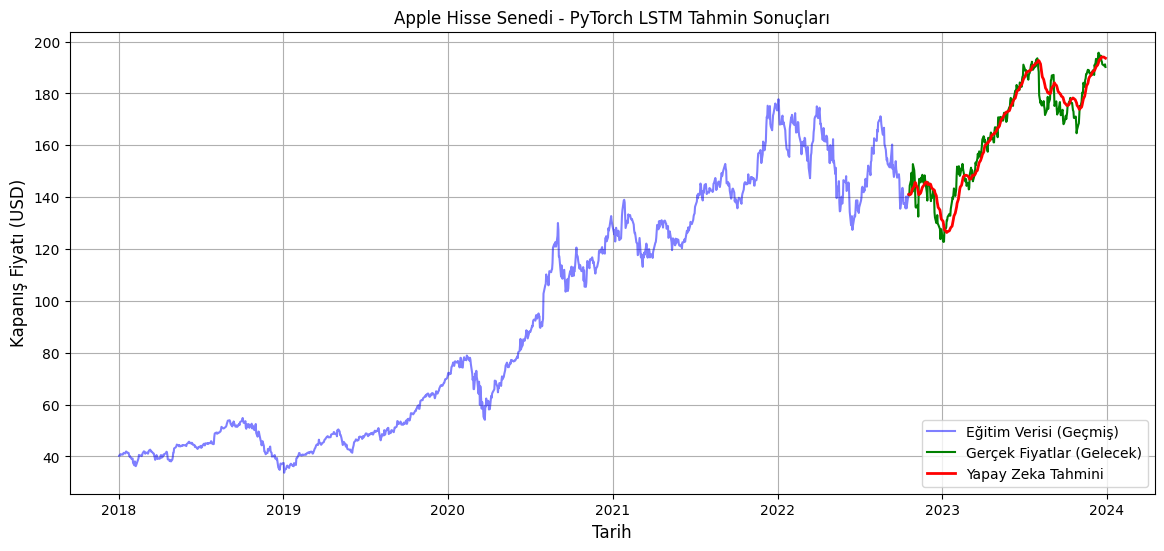

In [22]:
import time

epochs = 100

print("Yapay Zeka antrenmana başlıyor, geçmişten öğreniyor...")
start_time = time.time()

y_train_tensor_ayarlanmis = y_train_tensor.view(-1, 1)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    tahminler = model(x_train_tensor)

    loss = loss_function(tahminler, y_train_tensor_ayarlanmis)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Hata (Loss): {loss.item():.6f}')

print(f"Antrenman bitti! Toplam Süre: {time.time() - start_time:.2f} saniye.\n")

print("Model test ediliyor ve tahminler çiziliyor...")

test_verisi = olcekli_veri[egitim_veri_uzunlugu - 60: , :]
x_test = []

for i in range(60, len(test_verisi)):
    x_test.append(test_verisi[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
x_test_tensor = torch.from_numpy(x_test).type(torch.Tensor).to(device)

model.eval()
with torch.no_grad():
    test_tahminleri = model(x_test_tensor)

test_tahminleri = test_tahminleri.cpu().numpy()
test_tahminleri = scaler.inverse_transform(test_tahminleri)

tarihler = veri.index

plt.figure(figsize=(14,6))
plt.title('Apple Hisse Senedi - PyTorch LSTM Tahmin Sonuçları')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Kapanış Fiyatı (USD)', fontsize=12)

plt.plot(tarihler[:egitim_veri_uzunlugu], kapanis_verisi[:egitim_veri_uzunlugu], label='Eğitim Verisi (Geçmiş)', color='blue', alpha=0.5)

plt.plot(tarihler[egitim_veri_uzunlugu:], kapanis_verisi[egitim_veri_uzunlugu:], label='Gerçek Fiyatlar (Gelecek)', color='green')

plt.plot(tarihler[egitim_veri_uzunlugu:], test_tahminleri, label='Yapay Zeka Tahmini', color='red', linewidth=2)

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

GRU Modeli antrenmana başlıyor, LSTM'e rakip geliyor...
GRU Epoch [10/100], Hata (Loss): 0.155117
GRU Epoch [20/100], Hata (Loss): 0.060440
GRU Epoch [30/100], Hata (Loss): 0.053770
GRU Epoch [40/100], Hata (Loss): 0.036959
GRU Epoch [50/100], Hata (Loss): 0.027475
GRU Epoch [60/100], Hata (Loss): 0.015807
GRU Epoch [70/100], Hata (Loss): 0.004919
GRU Epoch [80/100], Hata (Loss): 0.000868
GRU Epoch [90/100], Hata (Loss): 0.001361
GRU Epoch [100/100], Hata (Loss): 0.000648
GRU Antrenman bitti! Toplam Süre: 50.91 saniye.

Her iki model test ediliyor ve performansları ölçülüyor...
----------------------------------------
🏆 PERFORMANS KARŞILAŞTIRMASI (Düşük olan daha iyidir)
LSTM Modeli -> MSE: 27.96 | RMSE: 5.29
GRU Modeli  -> MSE: 26.77 | RMSE: 5.17
----------------------------------------


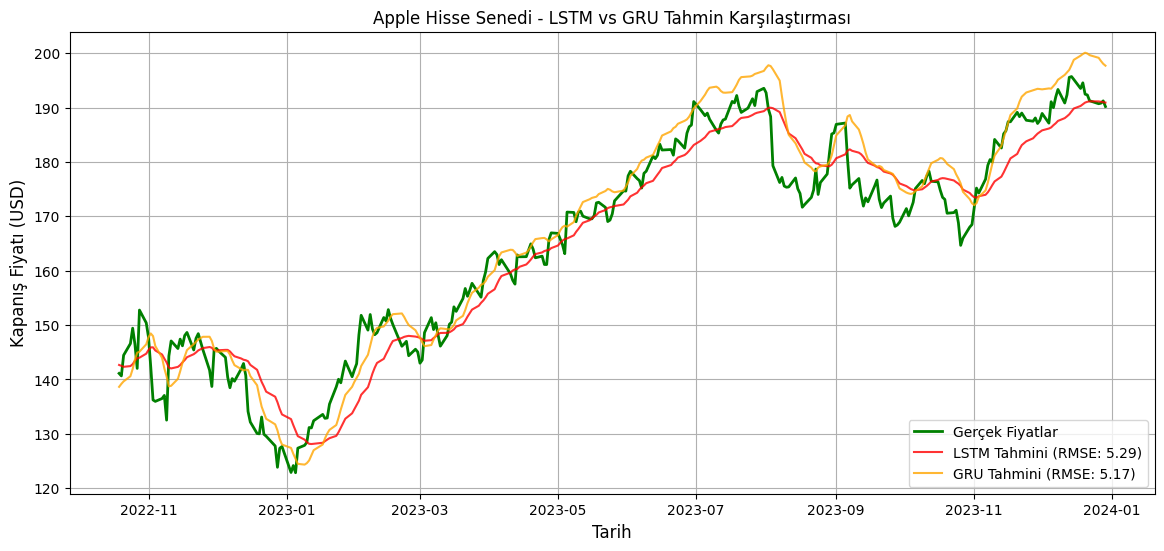

In [18]:
import math
from sklearn.metrics import mean_squared_error

class BorsaKahiniGRU(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.gru = nn.GRU(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        gru_out, _ = self.gru(input_seq)
        tahmin = self.linear(gru_out[:, -1, :])
        return tahmin

model_gru = BorsaKahiniGRU().to(device)
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.001)

print("GRU Modeli antrenmana başlıyor, LSTM'e rakip geliyor...")
start_time_gru = time.time()

for epoch in range(epochs):
    model_gru.train()
    optimizer_gru.zero_grad()

    tahminler_gru = model_gru(x_train_tensor)
    loss_gru = loss_function(tahminler_gru, y_train_tensor_ayarlanmis)

    loss_gru.backward()
    optimizer_gru.step()

    if (epoch+1) % 10 == 0:
        print(f'GRU Epoch [{epoch+1}/{epochs}], Hata (Loss): {loss_gru.item():.6f}')

print(f"GRU Antrenman bitti! Toplam Süre: {time.time() - start_time_gru:.2f} saniye.\n")

print("Her iki model test ediliyor ve performansları ölçülüyor...")
model.eval()
model_gru.eval()

with torch.no_grad():
    test_tahminleri_lstm = model(x_test_tensor)
    test_tahminleri_gru = model_gru(x_test_tensor)

tahmin_lstm_gercek = scaler.inverse_transform(test_tahminleri_lstm.cpu().numpy())
tahmin_gru_gercek = scaler.inverse_transform(test_tahminleri_gru.cpu().numpy())

mse_lstm = mean_squared_error(y_test, tahmin_lstm_gercek)
rmse_lstm = math.sqrt(mse_lstm)

mse_gru = mean_squared_error(y_test, tahmin_gru_gercek)
rmse_gru = math.sqrt(mse_gru)

print("-" * 40)
print("🏆 PERFORMANS KARŞILAŞTIRMASI (Düşük olan daha iyidir)")
print(f"LSTM Modeli -> MSE: {mse_lstm:.2f} | RMSE: {rmse_lstm:.2f}")
print(f"GRU Modeli  -> MSE: {mse_gru:.2f} | RMSE: {rmse_gru:.2f}")
print("-" * 40)

plt.figure(figsize=(14,6))
plt.title('Apple Hisse Senedi - LSTM vs GRU Tahmin Karşılaştırması')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Kapanış Fiyatı (USD)', fontsize=12)

plt.plot(tarihler[egitim_veri_uzunlugu:], kapanis_verisi[egitim_veri_uzunlugu:], label='Gerçek Fiyatlar', color='green', linewidth=2)

plt.plot(tarihler[egitim_veri_uzunlugu:], tahmin_lstm_gercek, label=f'LSTM Tahmini (RMSE: {rmse_lstm:.2f})', color='red', alpha=0.8)

plt.plot(tarihler[egitim_veri_uzunlugu:], tahmin_gru_gercek, label=f'GRU Tahmini (RMSE: {rmse_gru:.2f})', color='orange', alpha=0.8)

plt.legend(loc='lower right')
plt.grid(True)
plt.show()